# MFAA Chapter 9 Laboratory
**LBO Valuation Engine** (book §9.9)

The opening problem's spreadsheet, rebuilt with distributions: buyout equity under EBITDA risk, multiple regimes, sweep-driven debt, and optimal exit. Organizing display: the committee panel. Seed `20260900`.

In [1]:
import sys, numpy as np, matplotlib.pyplot as plt
sys.path.insert(0,'..')
from engine import ch09
from dataclasses import replace

## 1. E1 — Answer the committee
The deterministic base case sits at some percentile of the actual IRR distribution.

In [2]:
p = ch09.LBOParams(M=10000)
panel = ch09.committee_panel(p)
print(f"base-case IRR (deterministic): {panel['base_case_irr']:.4f}")
print(f"mean IRR: {panel['mean_irr']:.4f}, median IRR: {panel['median_irr']:.4f}")
print(f"impairment probability: {panel['impairment_prob']:.3f}")
print(f"the 'base case' sits at percentile {panel['base_percentile']:.2f} of the distribution")
print('IRR quantiles:', {k:round(v,4) for k,v in panel['irr_quantiles'].items()})

base-case IRR (deterministic): 0.1473
mean IRR: 0.0960, median IRR: 0.0926
impairment probability: 0.335
the 'base case' sits at percentile 0.61 of the distribution
IRR quantiles: {'q05': -1.0, 'q25': -0.0653, 'q50': 0.0926, 'q75': 0.2214, 'q95': 0.3896}


## 2. E2 — The leverage frontier
Where do the GP and LP optima diverge?

,leverage,mean_multiple,impairment_prob,breach_prob,mean_irr
0,0.40,1.716328,0.294167,0.045500,0.075537
1,0.45,1.755869,0.305167,0.092667,0.076394
2,0.50,1.804289,0.314500,0.158500,0.078899
3,0.55,1.865950,0.326167,0.245000,0.084504
4,0.60,1.947023,0.336667,0.347833,0.094614
5,0.65,2.057909,0.348500,0.459333,0.112302
6,0.70,2.214107,0.357167,0.568500,0.133690
7,0.75,2.444144,0.366500,0.670500,0.161995
8,0.80,2.805829,0.373500,0.759500,0.207519


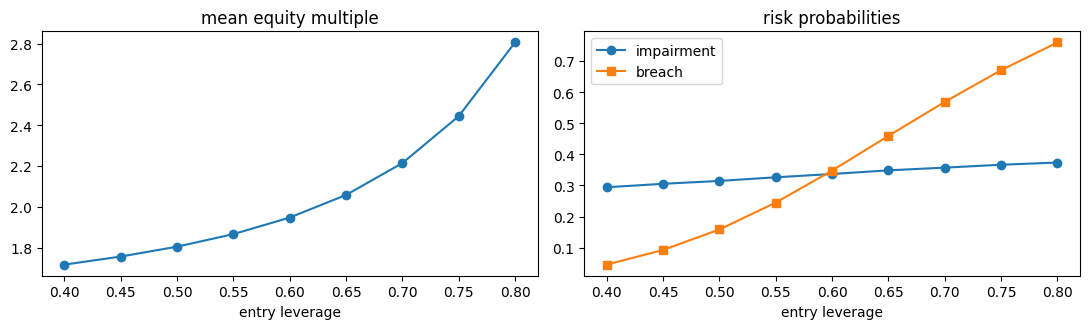

In [3]:
import pandas as pd
front = ch09.leverage_frontier(ch09.LBOParams(M=6000))
df = pd.DataFrame(front)
fig,ax=plt.subplots(1,2,figsize=(11,3.4))
ax[0].plot(df['leverage'], df['mean_multiple'],'o-'); ax[0].set_title('mean equity multiple'); ax[0].set_xlabel('entry leverage')
ax[1].plot(df['leverage'], df['impairment_prob'],'o-',label='impairment'); ax[1].plot(df['leverage'], df['breach_prob'],'s-',label='breach'); ax[1].legend(); ax[1].set_title('risk probabilities'); ax[1].set_xlabel('entry leverage')
plt.tight_layout(); df

## 3. Closed-form validation (Proposition 9.3, lognormal limit)

In [4]:
b = ch09.lognormal_benchmark(ch09.LBOParams(sweep=0, mult_hot=9.75, mult_cold=9.75, regime_rate=0))
print(f"closed-form equity (BS call on EV): {b['closed_form_equity']:.2f}")
v = ch09.validation_checks()
for k,d in v.items():
    if isinstance(d,dict): print(k, 'PASS' if d['pass_'] else 'FAIL')
print('ALL:', v['all_pass'])

closed-form equity (BS call on EV): 659.88


V1_lognormal PASS
V2_deterministic PASS
V3_leverage_monotone PASS
V4_timing_value PASS
V5_reproducible PASS
ALL: True
